# 1. Problem Statements
For the purpose of this Project we will be creating one such Recommendation Engine from the ground-up, where every single user, based on there area of interest and ratings, would be recommended a list of movies that are best suited for them

#2. Project Objective
1. Find out the list of most popular and liked genre
2. Create Model that finds the best suited Movie for one
user in every genre.
3. Find what Genre Movies have received the best and
worst ratings based on User Rating

#3. Data Description
1. ID–Contains the separate keys for
customer and movies.
2. Rating– A section contains the user
ratings for all the movies.
movie.
3. Genre–Highlights the category of the
4. Movie Name–Name of the movie with
respect to the movie id.

Data file having the list of movies and its genre, however,
Given dataset missing customer id informaion and ratings, hence synthetic data created:
1. Multiply the movie data with different customers(ids)
2. assign random ratings for each record

In [ ]:
# Install require additional libraries:
#scikit-surprise : contains singular value decomposition(SVD) packages
#helps to create recommendation engine.
!pip install scikit-surprise

In [ ]:
!pip install "numpy<2"

In [ ]:
#Import require basic packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_movies = pd.read_csv('netflix_titles-1.csv')

In [ ]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          8807 non-null   object
 1   Movie Name  8807 non-null   object
 2   Rating      8803 non-null   object
 3   Genre       8807 non-null   object
dtypes: object(4)
memory usage: 275.3+ KB


In [ ]:
df_movies.describe()

,ID,Movie Name,Rating,Genre
count,8807,8807,8803,8807
unique,8807,8804,17,514
top,s1,15-Aug,TV-MA,"Dramas, International Movies"
freq,1,2,3207,362


#4. Data Pre-processing Steps and Inspiration
1. anlyse data and its type
2. create synthedic data, since file contains only raw movie details and its genre.
3. ensure synthedic data is for multiple customer with multiple movie ratings.
4. ensure duplicates and null values handled in movies dataset
5. process require encoding and scaling with created dataset.


In [ ]:
df_movies[df_movies['Movie Name'].duplicated()]

,ID,Movie Name,Rating,Genre
5964,s5965,Feb-09,TV-14,"International TV Shows, TV Dramas"
5965,s5966,22-Jul,R,"Dramas, Thrillers"
5966,s5967,15-Aug,TV-14,"Comedies, Dramas, Independent Movies"


In [ ]:
# df_movies[df_movies['Movie Name'].str.lower().str.strip().duplicated(keep=False)].sort_values(by='Movie Name')
df_movies[df_movies['Movie Name'].str.lower().str.strip().duplicated(keep='first')]

,ID,Movie Name,Rating,Genre
5095,s5096,Fullmetal Alchemist,TV-14,"Anime Series, International TV Shows"
5751,s5752,DEATH NOTE,TV-14,"Anime Series, Crime TV Shows, International TV..."
5964,s5965,Feb-09,TV-14,"International TV Shows, TV Dramas"
5965,s5966,22-Jul,R,"Dramas, Thrillers"
5966,s5967,15-Aug,TV-14,"Comedies, Dramas, Independent Movies"
6529,s6530,Consequences,TV-MA,"Dramas, International Movies, Thrillers"
6705,s6706,Esperando La Carroza,NR,"Comedies, Cult Movies, International Movies"
7345,s7346,Love In A Puff,TV-MA,"Comedies, Dramas, International Movies"
8022,s8023,Sin Senos sí Hay Paraíso,TV-MA,"International TV Shows, Spanish-Language TV Sh..."


In [ ]:
df_movies = df_movies.drop(
    index=df_movies[df_movies['Movie Name'].str.lower().str.strip().duplicated(keep='first')].index
    )

In [ ]:
df_movies.shape

(8798, 4)

In [ ]:
# Genre code titled as Rating, hence changed the feature name
df_movies.rename(columns={'Rating': 'genre_code'}, inplace=True)

In [ ]:
# Checks for null and fill values
df_movies.isnull().sum()

,0
ID,0
Movie Name,0
genre_code,4
Genre,0


In [ ]:
df_movies[df_movies.isnull().any(axis=1)]

,ID,Movie Name,genre_code,Genre
5989,s5990,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,Movies
6827,s6828,Gargantia on the Verdurous Planet,NaN,"Anime Series, International TV Shows"
7312,s7313,Little Lunch,NaN,"Kids' TV, TV Comedies"
7537,s7538,My Honor Was Loyalty,NaN,Dramas


In [ ]:
df_movies.groupby(by=['Genre', 'genre_code'], as_index=False)[['Genre', 'genre_code']].value_counts()


,Genre,genre_code,count
0,Action & Adventure,PG-13,23
1,Action & Adventure,R,86
2,Action & Adventure,TV-14,2
3,Action & Adventure,TV-MA,17
4,"Action & Adventure, Anime Features",TV-MA,1
...,...,...,...
1233,TV Shows,TV-MA,5
1234,Thrillers,PG-13,8
1235,Thrillers,R,30
1236,Thrillers,TV-14,20


In [ ]:
df_movies['genre_code'] = df_movies['genre_code'].fillna(
                              df_movies['Genre'].map(
                                  df_movies.dropna(subset=['genre_code'])
                                          .drop_duplicates('Genre')
                                          .set_index('Genre')['genre_code']
                              )
                          )

In [ ]:
df_movies.isna().any().sum()

0

In [ ]:
# set size as 50K
SIZE = 50000

In [ ]:
# built 12k customer ids
customer_ids = np.random.randint(1, 12000, size=SIZE)
customer_ids.shape

(50000,)

In [ ]:
movie_ids = np.random.choice(df_movies['ID'], size=SIZE)

In [ ]:
ratings = np.random.normal(loc=3.5, scale=0.8, size=SIZE).round(0).astype(int)
ratings = np.clip(ratings, 1, 5)

In [ ]:
# create dataframe using generated data and merge with movies to get feedback dataset
df_ratings = pd.DataFrame({'movie_id': movie_ids,
                           'customer_id': customer_ids,
                           'rating': ratings
                           })

In [ ]:
df_mf = df_ratings.merge(right=df_movies, how='inner', left_on='movie_id', right_on='ID')\
        [['movie_id', 'Movie Name', 'genre_code', 'customer_id', 'rating']]

In [ ]:
df_mf.rename(columns={'Movie Name': 'movie_name'}, inplace=True)

In [ ]:
df_mf.sample(10)

,movie_id,movie_name,genre_code,customer_id,rating
45796,s219,Titletown High,TV-14,641,4
22946,s3163,It Comes at Night,R,189,5
38583,s2768,Ozark,TV-MA,2681,2
10078,s3861,Crime Diaries: Night Out,TV-MA,345,4
27926,s6806,Friend Request,R,5336,4
12184,s6169,Ankur Arora Murder Case,TV-14,7543,2
25618,s7278,LeapFrog: Phonics Farm,TV-Y,2679,5
47434,s8486,The Right One,TV-14,3920,2
45157,s2696,The Main Event,TV-G,1535,2
33617,s5743,West Coast,TV-MA,8597,4


In [ ]:
df_mf.duplicated(subset=['movie_id', 'customer_id']).sum()

7

In [ ]:
df_mf = df_mf.drop_duplicates(subset=['movie_id', 'customer_id'])

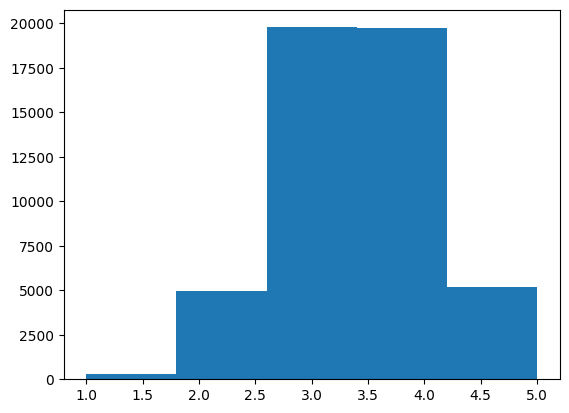

In [ ]:
plt.hist(df_mf['rating'], bins=5)
plt.show()

# 4. Data Pre-processing Steps and Inspiration
1. Genre code and movie id need to be encoded.
2. customer id already in numeric format

Inspiration : Intellipat recommendation system live class session.


In [ ]:
# Preprocessing - Encode the genre code
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_mf['movie_id'] = le.fit_transform(df_mf['movie_id'])
# df_mf['genre_code'] = le.fit_transform(df_mf['genre_code'])


In [ ]:
df_mf['movie_id']

,movie_id
0,6370
1,8412
2,8671
3,4612
4,2123
...,...
49995,3286
49996,938
49997,4708
49998,3909


#5. Choosing the Algorithm for the Project

---


Two strong approaches:

Matrix Factorization ensembling model(SVD/NMF) — works well for recommendation system.

Machine Learning Regression Models — DecisonTreeRegressor / RandomForestRegressor.

# 6. Motivation and Reasons for Choosing the Algorithm
1. Collabrative filtering (SVD) is famous and proven model for recommendation system hence SVD algorithm has been choosed.
2. It Handles sparse data efficiently.
3. It Captures latent patterns in user-movie interactions.

#7. Assumptions
Past ratings reflect future preferences.

Ratings are on a fixed scale (1–5).

In [ ]:
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
!pip install scikit-surprise

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2610396 sha256=2eeae4594d3c9715fd72450497d37976fd20952c28be5a3c76a0b4327e2d59e8
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [ ]:
help(cross_validate)

Help on function cross_validate in module surprise.model_selection.validation:

cross_validate(algo, data, measures=['rmse', 'mae'], cv=None, return_train_measures=False, n_jobs=1, pre_dispatch='2*n_jobs', verbose=False)
    Run a cross validation procedure for a given algorithm, reporting accuracy
    measures and computation times.

    See an example in the :ref:`User Guide <cross_validate_example>`.

    Args:
        algo(:obj:`AlgoBase             <surprise.prediction_algorithms.algo_base.AlgoBase>`):
            The algorithm to evaluate.
        data(:obj:`Dataset <surprise.dataset.Dataset>`): The dataset on which
            to evaluate the algorithm.
        measures(list of string): The performance measures to compute. Allowed
            names are function names as defined in the :mod:`accuracy
            <surprise.accuracy>` module. Default is ``['rmse', 'mae']``.
        cv(cross-validation iterator, int or ``None``): Determines how the
            ``data`` parameter wil

In [ ]:
reader = Reader()
# Exact three features for svd model
svd_features = Dataset.load_from_df(df_mf[['customer_id', 'movie_id', 'rating']],
                                    reader)
model_svd = SVD()


#8. Model Evaluation and Techniques
RMSE (Root Mean Squared Error) — measures prediction accuracy.

MAE (Mean Absolute Error) — measures deviation in ratings.

In [ ]:
cross_validate(model_svd, svd_features, measures=['RMSE', 'MAE'], cv=3, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.8579  0.8508  0.8529  0.8539  0.0030  
MAE (testset)     0.7195  0.7144  0.7145  0.7161  0.0024  
Fit time          1.14    0.87    0.78    0.93    0.15    
Test time         0.11    0.09    0.09    0.10    0.01    


{'test_rmse': array([0.85789589, 0.85084823, 0.85292032]),
 'test_mae': array([0.71948635, 0.71441577, 0.71449183]),
 'fit_time': (1.1355085372924805, 0.8693487644195557, 0.7766249179840088),
 'test_time': (0.11060142517089844, 0.09346413612365723, 0.08897209167480469)}

# Objective
1. Find out the list of most popular and liked genre
2. Create Model that finds the best suited Movie for one
user in every genre.
3. Find what Genre Movies have received the best and
worst ratings based on User Rating

In [ ]:
train_dataset = svd_features.build_full_trainset()
model_svd.fit(train_dataset)

In [ ]:
cust_id = df_mf.sample()['customer_id'].values[0]
cust_id

9593

In [ ]:
df_mf[df_mf['customer_id'] != cust_id].sample()

,movie_id,movie_name,genre_code,customer_id,rating
18766,2572,"Liar, Liar, Vampire",TV-PG,5839,4


In [ ]:
movie_id = 4925

In [ ]:
model_svd.predict(cust_id, movie_id).est #predicted rating

3.681033320611867

**Find out the list of most popular and liked genre**

In [ ]:
# df_mf[df_mf['rating'] >= 4].groupby(by='genre_code')['rating'].count().sort_values(ascending=False).head(5)
df_mf.groupby(by=['genre_code'])['rating'].mean().sort_values(ascending=False).head(5)

,rating
genre_code,
84 min,3.857143
TV-Y7-FV,3.692308
NC-17,3.533333
PG,3.524909
TV-Y7,3.511494


**Create Model that finds the best suited Movie for one user in every genre.**

In [ ]:
cust_id = df_mf['customer_id'].sample().values[0]
print(cust_id)

11940


In [ ]:
cust_id

11940

In [ ]:
df_cust_predict1 = df_mf.groupby(by=['movie_id', 'movie_name'], as_index=False)\
[['movie_id', 'movie_name', 'genre_code']].first()

In [ ]:
df_cust_predict1['predicted_rating'] = df_cust_predict1['movie_id']\
.apply(lambda mi: model_svd.predict(cust_id, mi).est.round(0))

In [ ]:
# df_cust_predict1.loc[df_cust_predict1.groupby(by=['genre_code'])['predicted_rating'].idxmax()]
df_cust_predict1.sort_values(by=['genre_code', 'predicted_rating'], ascending=[True, False])\
.drop_duplicates(subset=['genre_code'], keep='first')

,movie_id,movie_name,genre_code,predicted_rating
5329,5329,Louis C.K.: Live at the Comedy Store,66 min,4.0
5029,5029,Louis C.K. 2017,74 min,4.0
5307,5307,Louis C.K.: Hilarious,84 min,4.0
89,89,A Champion Heart,G,4.0
4721,4721,Swearnet: The Movie,NC-17,4.0
5500,5500,(T)ERROR,NR,4.0
24,24,Lagaan,PG,4.0
0,0,Dick Johnson Is Dead,PG-13,4.0
17,17,Miss Sloane,R,4.0
4,4,Oloibiri,TV-14,4.0


In [ ]:
df_cust_predict1.groupby('genre_code', group_keys=True) \
    .apply(lambda g: g.nlargest(3, 'predicted_rating'))
# first 3 movies for customer in each genre based on predicted rating


/tmp/ipython-input-1792907411.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(3, 'predicted_rating')) # first 3 movies for customer in each genre based on predicted rating


movie_id                                         movie_name  \
genre_code                                                                     
66 min     5329      5329               Louis C.K.: Live at the Comedy Store   
74 min     5029      5029                                    Louis C.K. 2017   
84 min     5307      5307                              Louis C.K.: Hilarious   
G          89          89                                   A Champion Heart   
           620        620                                             Canvas   
           2116      2116               A Shaun the Sheep Movie: Farmageddon   
NC-17      4721      4721                                Swearnet: The Movie   
           5908      5908                          Blue Is the Warmest Color   
           6929      6929                                          Lady-Like   
NR         5500      5500                                           (T)ERROR   
           5517      5517                                         13 Cameras   
           5550      5550                                        4th Man Out   
PG         24          24                                             Lagaan   
           27          27                                   Taare Zameen Par   
           115        115                           Escape from Planet Earth   
PG-13      0            0                               Dick Johnson Is Dead   
           1            1                                       The Starling   
           99          99                                      Thunder Force   
R          17          17                                        Miss Sloane   
           19          19                                        American Me   
           32          32                                       Crimson Peak   
TV-14      4            4                                           Oloibiri   
           15          15                                       Free to Play   
           22          22                            Jaane Tu... Ya Jaane Na   
TV-G       78          78                                             Bunk'd   
           100        100                                          Dive Club   
           205        205                Reframe THEATER EXPERIENCE with you   
TV-MA      3            3                                           Stowaway   
           5            5                                       Tell Me When   
           6            6                                               Zero   
TV-PG      44          44                                     Dancing Angels   
           49          49                      Garth Brooks: The Road I’m On   
           64          64                                     Ajaibnya Cinta   
TV-Y       7            7                                 Izzy's Koala World   
           8            8                 Keymon and Nani in Space Adventure   
           10          10                        Motu Patlu in Octupus World   
TV-Y7      9            9                           Motu Patlu Dino Invasion   
           12          12                            Tobot Galaxy Detectives   
           14          14                    Rudra: The Rise of King Pharaoh   
TV-Y7-FV   6176      6176                                       Dear Dracula   
           6959      6959  LEGO Ninjago: Masters of Spinjitzu: Day of the...   
           6989      6989                Little Singham aur Kaal ka Mahajaal   
UR         7728      7728                                           Sex Doll   
           8617      8617                      You Don't Mess with the Zohan   
           6705      6705                                      Immoral Tales   

                genre_code  predicted_rating  
genre_code                                    
66 min     5329     66 min               4.0  
74 min     5029     74 min               4.0  
84 min     5307     84 min               4.0  
G          89        

**Find what Genre Movies have received the best and
worst ratings based on User Rating**

In [ ]:
df_mf.groupby(by=['genre_code'])['rating'].mean().sort_values(ascending=False)

,rating
genre_code,
84 min,3.857143
TV-Y7-FV,3.692308
NC-17,3.533333
PG,3.524909
TV-Y7,3.511494
TV-PG,3.499189
TV-MA,3.497652
PG-13,3.490260
TV-Y,3.486879


In [ ]:
df_mf.groupby(by=['genre_code'])['rating'].mean().sort_values(ascending=False).head(3)

,rating
genre_code,
84 min,3.857143
TV-Y7-FV,3.692308
NC-17,3.533333


In [ ]:
df_mf.groupby(by=['genre_code'])['rating'].mean().sort_values(ascending=True).head(3)

,rating
genre_code,
66 min,3.250000
74 min,3.416667
G,3.416667


#9. Inferences from the model
RMSE around 0.8–0.9 indicates strong predictions.

#10. Future Possibilities of the Project
Hybrid models (content + collaborative).

Deep learning models (Neural Collaborative Filtering).

Sentiment analysis on movie reviews to enhance predictions.




#11. Conclusion
The system effectively predicts movie ratings and can be integrated into a recommendation engine. Performance can improve with more data and advanced algorithms.

#12. References
1. Scikit-learn Documentation (https://scikit-learn.org/)
2. Intellipat sessios and documents
